# Ethereum Mainnet USDC/USDT Exploration

This notebook is a market-expansion notebook for **USDC/USDT on Ethereum Mainnet**.

It is designed to answer one question before you spend more time on engineering: **could this market produce better post-cost arbitrage economics than the current Ethereum `WBTC/WETH` setup?**

Why this variant is worth testing:
- Stablecoin pairs should reduce directional volatility and often have smaller slippage for a given dollar notional.
- The trade-off is that observed price dislocations are usually much tighter, so break-even math matters even more.
- This is a good test of whether lower pool fee tiers can compensate for expensive Ethereum gas.

In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

MARKET_SPEC = {'slug': 'mainnet_usdc_usdt', 'scope_type': 'pair expansion', 'chain_family': 'EVM', 'chain_name': 'Ethereum Mainnet', 'pair': 'USDC/USDT', 'base_token': 'USDC', 'quote_token': 'USDT', 'goal': 'Test whether a stable/stable pair can reduce slippage and fee drag enough to justify the tighter spread profile.', 'hypothesis': 'Even with high mainnet gas, lower slippage and tighter fee tiers may still leave room if transient spreads are large enough.', 'pipeline_fit': 'Low to medium. The event model still fits, but the current notebook is hard-coded around WBTC/WETH naming and notional choices.', 'output_prefix': 'mainnet_usdc_usdt', 'work_items': [{'area': 'Token generalization', 'change_needed': 'Replace WBTC/WETH-specific column names with generic base_token and quote_token naming.', 'priority': 'high'}, {'area': 'Decimals', 'change_needed': 'Rescale reserve parsing for 6-decimal stablecoins instead of the current token assumptions.', 'priority': 'high'}, {'area': 'Notional sizing', 'change_needed': 'Replace arbitrage_notional_wbtc with a generic dollar or base-token notional.', 'priority': 'high'}, {'area': 'Fee tiers', 'change_needed': 'Verify which stable-pair fee tiers and venues should be modeled.', 'priority': 'medium'}, {'area': 'Outputs', 'change_needed': 'Write USDC/USDT artifacts into dedicated folders so they do not overwrite WBTC/WETH outputs.', 'priority': 'medium'}]}
ASSUMPTIONS = {'trade_notional_usd': 10000, 'fee_tiers_bps': [1, 5], 'gas_cost_usd_scenarios': {'optimistic': 2.0, 'base': 10.0, 'stress': 30.0}, 'slippage_buffer_bps': 2, 'spread_grid_bps': [1, 2, 5, 10, 20]}

summary_rows = [
    {'field': 'scope_type', 'value': MARKET_SPEC['scope_type']},
    {'field': 'chain_family', 'value': MARKET_SPEC['chain_family']},
    {'field': 'chain_name', 'value': MARKET_SPEC['chain_name']},
    {'field': 'pair', 'value': MARKET_SPEC['pair']},
    {'field': 'base_token', 'value': MARKET_SPEC['base_token']},
    {'field': 'quote_token', 'value': MARKET_SPEC['quote_token']},
    {'field': 'notebook_goal', 'value': MARKET_SPEC['goal']},
    {'field': 'main_hypothesis', 'value': MARKET_SPEC['hypothesis']},
    {'field': 'current_pipeline_fit', 'value': MARKET_SPEC['pipeline_fit']},
    {'field': 'suggested_output_prefix', 'value': MARKET_SPEC['output_prefix']},
]

display(pd.DataFrame(summary_rows))
display(Markdown(
    f"This notebook is a **scoping notebook**, not a claim that `02_end_to_end_mev_pipeline.ipynb` can run unchanged for {MARKET_SPEC['pair']} on {MARKET_SPEC['chain_name']}. "
    "Use it to test whether lower gas, lower LP fees, or better market structure could make the economics more attractive before doing the heavier engineering work."
))

,field,value
0,scope_type,pair expansion
1,chain_family,EVM
2,chain_name,Ethereum Mainnet
3,pair,USDC/USDT
4,base_token,USDC
5,quote_token,USDT
6,notebook_goal,Test whether a stable/stable pair can reduce s...
7,main_hypothesis,"Even with high mainnet gas, lower slippage and..."
8,current_pipeline_fit,"Low to medium. The event model still fits, but..."
9,suggested_output_prefix,mainnet_usdc_usdt


This notebook is a **scoping notebook**, not a claim that `02_end_to_end_mev_pipeline.ipynb` can run unchanged for USDC/USDT on Ethereum Mainnet. Use it to test whether lower gas, lower LP fees, or better market structure could make the economics more attractive before doing the heavier engineering work.

## Break-Even Spread Scenarios

The table below is intentionally simple. It treats the market as viable only when the observable cross-venue spread is larger than:

`round-trip DEX fees + gas cost + a slippage buffer`

The assumptions are editable. The point is not to forecast exact live profitability, but to see whether this market still looks plausible after costs.

In [2]:
fee_tiers_bps = ASSUMPTIONS['fee_tiers_bps']
gas_cost_usd_scenarios = ASSUMPTIONS['gas_cost_usd_scenarios']
trade_notional_usd = ASSUMPTIONS['trade_notional_usd']
slippage_buffer_bps = ASSUMPTIONS['slippage_buffer_bps']
spread_grid_bps = ASSUMPTIONS['spread_grid_bps']

rows = []
for fee_tier_bps in fee_tiers_bps:
    round_trip_dex_fee_bps = fee_tier_bps * 2
    for gas_label, gas_cost_usd in gas_cost_usd_scenarios.items():
        gas_bps = (gas_cost_usd / trade_notional_usd) * 10_000.0
        required_spread_bps = round_trip_dex_fee_bps + slippage_buffer_bps + gas_bps
        for observable_spread_bps in spread_grid_bps:
            rows.append(
                {
                    'fee_tier_bps_per_side': fee_tier_bps,
                    'gas_scenario': gas_label,
                    'gas_cost_usd': gas_cost_usd,
                    'gas_cost_bps': gas_bps,
                    'slippage_buffer_bps': slippage_buffer_bps,
                    'required_spread_bps': required_spread_bps,
                    'observable_spread_bps': observable_spread_bps,
                    'net_edge_after_costs_bps': observable_spread_bps - required_spread_bps,
                }
            )

scenario_table = pd.DataFrame(rows)
break_even = (
    scenario_table[['fee_tier_bps_per_side', 'gas_scenario', 'gas_cost_usd', 'required_spread_bps']]
    .drop_duplicates()
    .sort_values(['fee_tier_bps_per_side', 'gas_cost_usd'])
    .reset_index(drop=True)
)
viability = scenario_table.pivot_table(
    index=['fee_tier_bps_per_side', 'gas_scenario'],
    columns='observable_spread_bps',
    values='net_edge_after_costs_bps',
)

display(pd.DataFrame([
    {'assumption': 'trade_notional_usd', 'value': trade_notional_usd},
    {'assumption': 'slippage_buffer_bps', 'value': slippage_buffer_bps},
    {'assumption': 'fee_tiers_bps_per_side', 'value': fee_tiers_bps},
    {'assumption': 'gas_cost_usd_scenarios', 'value': gas_cost_usd_scenarios},
    {'assumption': 'spread_grid_bps', 'value': spread_grid_bps},
]))
display(break_even)
display(viability)

,assumption,value
0,trade_notional_usd,10000
1,slippage_buffer_bps,2
2,fee_tiers_bps_per_side,"[1, 5]"
3,gas_cost_usd_scenarios,"{'optimistic': 2.0, 'base': 10.0, 'stress': 30.0}"
4,spread_grid_bps,"[1, 2, 5, 10, 20]"


,fee_tier_bps_per_side,gas_scenario,gas_cost_usd,required_spread_bps
0,1,optimistic,2.0,6.0
1,1,base,10.0,14.0
2,1,stress,30.0,34.0
3,5,optimistic,2.0,14.0
4,5,base,10.0,22.0
5,5,stress,30.0,42.0


observable_spread_bps                 1     2     5     10    20
fee_tier_bps_per_side gas_scenario                              
1                     base         -13.0 -12.0  -9.0  -4.0   6.0
                      optimistic    -5.0  -4.0  -1.0   4.0  14.0
                      stress       -33.0 -32.0 -29.0 -24.0 -14.0
5                     base         -21.0 -20.0 -17.0 -12.0  -2.0
                      optimistic   -13.0 -12.0  -9.0  -4.0   6.0
                      stress       -41.0 -40.0 -37.0 -32.0 -22.0

## Real Pool Dataset Fetch

This section downloads real pool-level OHLCV data from the GeckoTerminal public API and writes it into market-specific folders under `data/` and `outputs/`.

The dataset is not the same as the second-level reserve reconstruction in notebook `02`: it is an hourly public market-data feed. That makes it suitable for screening real cross-pool spreads across new markets before investing in a full RPC/event-log pipeline.


In [3]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from market_data import dataset_summary_frame, load_or_fetch_market_dataset

REFRESH_MARKET_DATA = False

market_dataset = load_or_fetch_market_dataset(
    MARKET_SPEC['output_prefix'],
    ASSUMPTIONS,
    project_root=PROJECT_ROOT,
    refresh=REFRESH_MARKET_DATA,
)

selected_pools = market_dataset['selected_pools']
pool_ohlcv = market_dataset['pool_ohlcv']
market_edges = market_dataset['market_edges']
real_size_sensitivity = market_dataset['size_sensitivity']

display(dataset_summary_frame(market_dataset))
display(selected_pools[['pool_name', 'dex_id', 'pool_address', 'reserve_in_usd', 'volume_h24_usd', 'fee_bps_from_name']])
display(market_edges.tail(10))


,field,value
0,source,GeckoTerminal Public API
1,network,eth
2,search_query,USDC USDT
3,target_asset,USDC
4,selected_pool_count,3
5,pool_ohlcv_rows,2160
6,market_edge_rows,720
7,loaded_from_cache,True
8,pool_ohlcv_path,/Users/bilguuntsolmon/Desktop/main/uni/finance...
9,market_edges_path,/Users/bilguuntsolmon/Desktop/main/uni/finance...


,pool_name,dex_id,pool_address,reserve_in_usd,volume_h24_usd,fee_bps_from_name
0,USDC / USDT 0.001%,uniswap-v4-ethereum,0x8aa4e11cbdf30eedc92100f4c8a31ff748e201d44712...,1.443576e+09,5.494132e+07,0.1
1,USDC / USDT,fluid-ethereum,0x667701e51b4d1ca244f17c78f7ab8744b4c99f9b,5.220187e+07,1.682021e+08,NaN
2,DAI / USDC / USDT,curve,0xbebc44782c7db0a1a60cb6fe97d0b483032ff1c7,1.625342e+08,3.778260e+07,NaN


,timestamp,pool_count,buy_pool_address,sell_pool_address,buy_pool_name,sell_pool_name,buy_dex,sell_dex,buy_price_usd,sell_price_usd,observed_spread_bps,total_volume_usd
710,2026-04-14 22:00:00+00:00,3,0xbebc44782c7db0a1a60cb6fe97d0b483032ff1c7,0x8aa4e11cbdf30eedc92100f4c8a31ff748e201d44712...,DAI / USDC / USDT,USDC / USDT 0.001%,curve,uniswap-v4-ethereum,0.991846,0.999901,81.209637,1.615175e+06
711,2026-04-14 23:00:00+00:00,3,0xbebc44782c7db0a1a60cb6fe97d0b483032ff1c7,0x667701e51b4d1ca244f17c78f7ab8744b4c99f9b,DAI / USDC / USDT,USDC / USDT,curve,fluid-ethereum,0.996245,0.999230,29.960826,1.056398e+06
712,2026-04-15 00:00:00+00:00,3,0xbebc44782c7db0a1a60cb6fe97d0b483032ff1c7,0x667701e51b4d1ca244f17c78f7ab8744b4c99f9b,DAI / USDC / USDT,USDC / USDT,curve,fluid-ethereum,0.996245,0.999003,27.683975,4.035890e+06
713,2026-04-15 01:00:00+00:00,3,0xbebc44782c7db0a1a60cb6fe97d0b483032ff1c7,0x667701e51b4d1ca244f17c78f7ab8744b4c99f9b,DAI / USDC / USDT,USDC / USDT,curve,fluid-ethereum,0.994320,1.000221,59.340827,2.942589e+06
714,2026-04-15 02:00:00+00:00,2,0x8aa4e11cbdf30eedc92100f4c8a31ff748e201d44712...,0x667701e51b4d1ca244f17c78f7ab8744b4c99f9b,USDC / USDT 0.001%,USDC / USDT,uniswap-v4-ethereum,fluid-ethereum,0.999007,0.999072,0.645240,3.735795e+06
715,2026-04-15 03:00:00+00:00,2,0x8aa4e11cbdf30eedc92100f4c8a31ff748e201d44712...,0x667701e51b4d1ca244f17c78f7ab8744b4c99f9b,USDC / USDT 0.001%,USDC / USDT,uniswap-v4-ethereum,fluid-ethereum,0.999040,0.999316,2.760631,9.617161e+05
716,2026-04-15 04:00:00+00:00,2,0x8aa4e11cbdf30eedc92100f4c8a31ff748e201d44712...,0x667701e51b4d1ca244f17c78f7ab8744b4c99f9b,USDC / USDT 0.001%,USDC / USDT,uniswap-v4-ethereum,fluid-ethereum,0.999438,1.000163,7.258360,4.146832e+05
717,2026-04-15 05:00:00+00:00,2,0x8aa4e11cbdf30eedc92100f4c8a31ff748e201d44712...,0x667701e51b4d1ca244f17c78f7ab8744b4c99f9b,USDC / USDT 0.001%,USDC / USDT,uniswap-v4-ethereum,fluid-ethereum,0.998976,0.999435,4.596957,1.546460e+06
718,2026-04-15 06:00:00+00:00,2,0x667701e51b4d1ca244f17c78f7ab8744b4c99f9b,0x8aa4e11cbdf30eedc92100f4c8a31ff748e201d44712...,USDC / USDT,USDC / USDT 0.001%,fluid-ethereum,uniswap-v4-ethereum,0.999098,1.000024,9.272815,3.485405e+06
719,2026-04-15 07:00:00+00:00,2,0x8aa4e11cbdf30eedc92100f4c8a31ff748e201d44712...,0x667701e51b4d1ca244f17c78f7ab8744b4c99f9b,USDC / USDT 0.001%,USDC / USDT,uniswap-v4-ethereum,fluid-ethereum,0.999915,1.000417,5.023693,1.870699e+06


## Required Changes Versus The Current Notebook

The current `02_end_to_end_mev_pipeline.ipynb` notebook is still tied to Ethereum mainnet and `WBTC/WETH` naming. These are the minimum changes needed before a real dataset build would be credible.

In [4]:
work_items = pd.DataFrame(MARKET_SPEC['work_items'])
path_plan = pd.DataFrame(
    [
        {'artifact': 'raw data', 'path': f"data/{MARKET_SPEC['output_prefix']}/raw"},
        {'artifact': 'curated data', 'path': f"data/{MARKET_SPEC['output_prefix']}/curated"},
        {'artifact': 'reports', 'path': f"outputs/{MARKET_SPEC['output_prefix']}/report"},
        {'artifact': 'metadata', 'path': f"outputs/{MARKET_SPEC['output_prefix']}/metadata"},
    ]
)

display(work_items)
display(path_plan)
display(Markdown(
    "Suggested decision rule: if the required spread stays comfortably below the kind of cross-venue spreads you expect to observe for this market, it is a reasonable candidate for a full pipeline implementation. Otherwise, the engineering effort is likely not worth it yet."
))

,area,change_needed,priority
0,Token generalization,Replace WBTC/WETH-specific column names with g...,high
1,Decimals,Rescale reserve parsing for 6-decimal stableco...,high
2,Notional sizing,Replace arbitrage_notional_wbtc with a generic...,high
3,Fee tiers,Verify which stable-pair fee tiers and venues ...,medium
4,Outputs,Write USDC/USDT artifacts into dedicated folde...,medium


,artifact,path
0,raw data,data/mainnet_usdc_usdt/raw
1,curated data,data/mainnet_usdc_usdt/curated
2,reports,outputs/mainnet_usdc_usdt/report
3,metadata,outputs/mainnet_usdc_usdt/metadata


Suggested decision rule: if the required spread stays comfortably below the kind of cross-venue spreads you expect to observe for this market, it is a reasonable candidate for a full pipeline implementation. Otherwise, the engineering effort is likely not worth it yet.

## Real Dataset Asset-Size Sweep

This section is the real-data analogue of the size-sensitivity charts in `02_end_to_end_mev_pipeline.ipynb`.

It starts with the observed hourly spread between the selected pools, then subtracts a size-scaled slippage buffer. The gross line excludes DEX fees and gas. The net line uses the lowest fee tier and base gas scenario from `ASSUMPTIONS`, so it should still be treated as a screening estimate rather than an execution-ready backtest.


,asset_notional_usd,asset_size_multiple,observed_intervals,size_adjusted_slippage_bps,modeled_fee_tier_bps_per_side,modeled_base_gas_cost_usd,modeled_gas_bps,gross_positive_intervals,gross_positive_share_pct,net_positive_intervals,net_positive_share_pct,mean_gross_edge_bps,median_gross_edge_bps,max_gross_edge_bps,mean_net_edge_bps,median_net_edge_bps,max_net_edge_bps
0,1000.0,0.10,720,0.63,1.0,10.0,100.0,720,100.00,133,18.47,73.99,73.58,158.52,-28.01,-28.42,56.52
1,2500.0,0.25,720,1.00,1.0,10.0,40.0,718,99.72,614,85.28,73.62,73.21,158.15,31.62,31.21,116.15
2,5000.0,0.50,720,1.41,1.0,10.0,20.0,718,99.72,662,91.94,73.21,72.80,157.74,51.21,50.80,135.74
3,10000.0,1.00,720,2.00,1.0,10.0,10.0,718,99.72,681,94.58,72.62,72.21,157.15,60.62,60.21,145.15
4,20000.0,2.00,720,2.83,1.0,10.0,5.0,717,99.58,695,96.53,71.80,71.38,156.32,64.80,64.38,149.32
5,50000.0,5.00,720,4.47,1.0,10.0,2.0,714,99.17,702,97.50,70.15,69.74,154.68,66.15,65.74,150.68
6,100000.0,10.00,720,6.32,1.0,10.0,1.0,708,98.33,699,97.08,68.30,67.89,152.83,65.30,64.89,149.83
7,200000.0,20.00,720,8.94,1.0,10.0,0.5,701,97.36,691,95.97,65.68,65.27,150.21,63.18,62.77,147.71


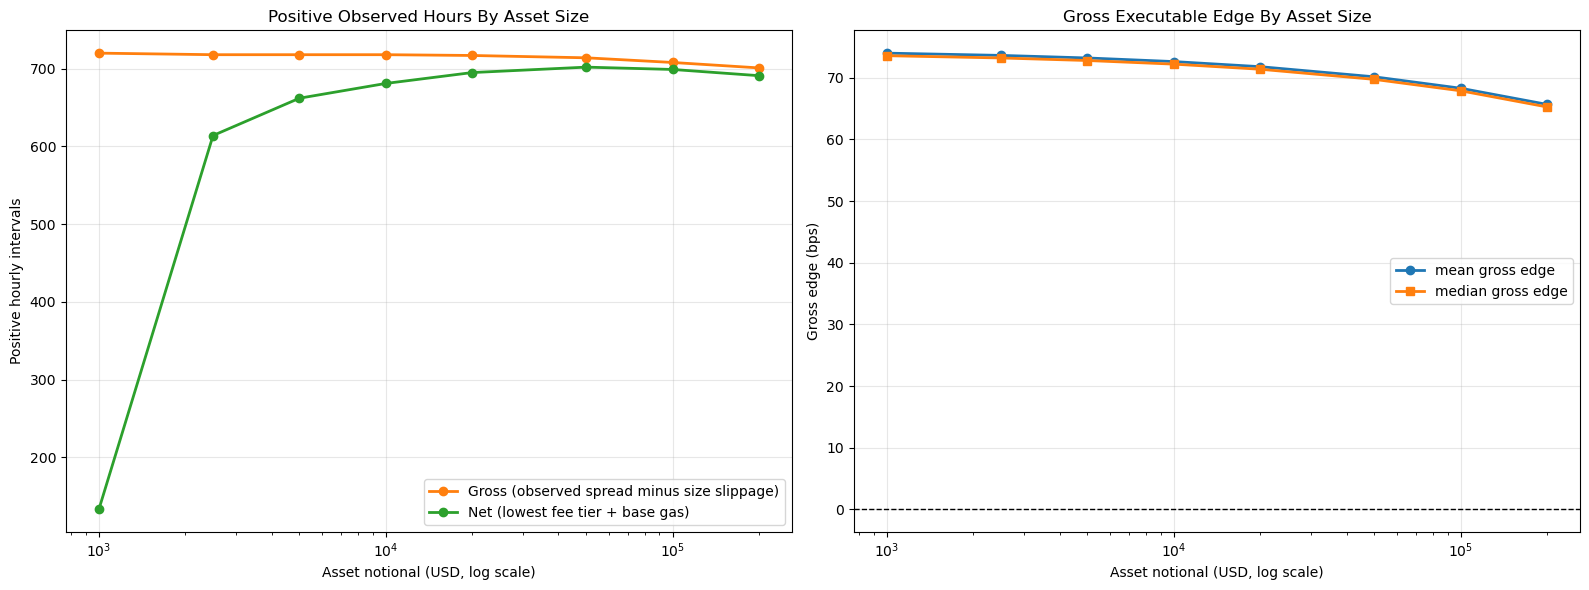

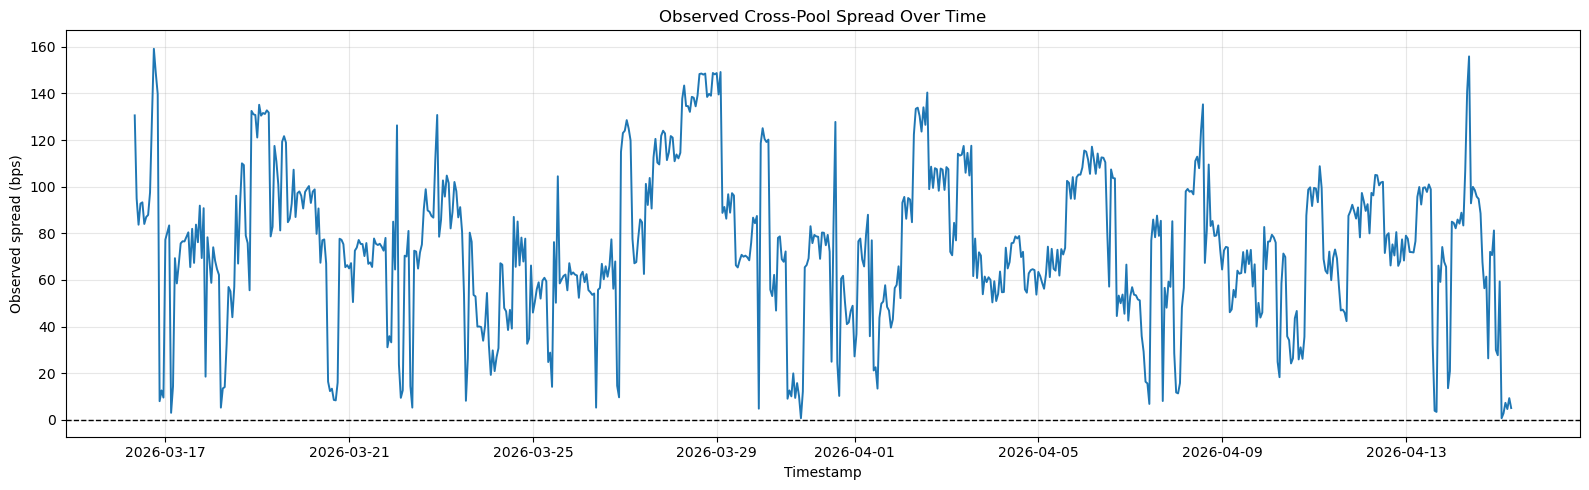

Most supportive observed trade size: **$50,000** with **702** net-positive hourly intervals and mean net edge of **66.15 bps**.

In [5]:
if real_size_sensitivity.empty:
    raise RuntimeError('No real size-sensitivity data was built. Check the selected pools and fetched OHLCV rows above.')

display(real_size_sensitivity.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(
    real_size_sensitivity['asset_notional_usd'],
    real_size_sensitivity['gross_positive_intervals'],
    marker='o',
    linewidth=2,
    label='Gross (observed spread minus size slippage)',
    color='#ff7f0e',
)
axes[0].plot(
    real_size_sensitivity['asset_notional_usd'],
    real_size_sensitivity['net_positive_intervals'],
    marker='o',
    linewidth=2,
    label='Net (lowest fee tier + base gas)',
    color='#2ca02c',
)
axes[0].set_xscale('log')
axes[0].set_title('Positive Observed Hours By Asset Size')
axes[0].set_xlabel('Asset notional (USD, log scale)')
axes[0].set_ylabel('Positive hourly intervals')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    real_size_sensitivity['asset_notional_usd'],
    real_size_sensitivity['mean_gross_edge_bps'],
    marker='o',
    linewidth=2,
    label='mean gross edge',
)
axes[1].plot(
    real_size_sensitivity['asset_notional_usd'],
    real_size_sensitivity['median_gross_edge_bps'],
    marker='s',
    linewidth=2,
    label='median gross edge',
)
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_xscale('log')
axes[1].set_title('Gross Executable Edge By Asset Size')
axes[1].set_xlabel('Asset notional (USD, log scale)')
axes[1].set_ylabel('Gross edge (bps)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(market_edges['timestamp'], market_edges['observed_spread_bps'], linewidth=1.4, color='#1f77b4')
ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Observed Cross-Pool Spread Over Time')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Observed spread (bps)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_net_row = real_size_sensitivity.sort_values(
    ['net_positive_intervals', 'mean_net_edge_bps', 'asset_notional_usd'],
    ascending=[False, False, True],
).iloc[0]

if best_net_row['net_positive_intervals'] > 0 and best_net_row['mean_net_edge_bps'] > 0:
    display(Markdown(
        f"Most supportive observed trade size: **${best_net_row['asset_notional_usd']:,.0f}** "
        f"with **{int(best_net_row['net_positive_intervals'])}** net-positive hourly intervals "
        f"and mean net edge of **{best_net_row['mean_net_edge_bps']:.2f} bps**."
    ))
elif best_net_row['net_positive_intervals'] > 0:
    display(Markdown(
        f"Most permissive observed trade size: **${best_net_row['asset_notional_usd']:,.0f}** "
        f"with **{int(best_net_row['net_positive_intervals'])}** net-positive hourly intervals, "
        f"but the average modeled net edge is still **{best_net_row['mean_net_edge_bps']:.2f} bps**. "
        "That means the strategy only works in selective observed spread windows under the current assumptions."
    ))
else:
    display(Markdown(
        "No asset-size bucket remains net positive under the current real pool dataset and cost assumptions. "
        "That does not prove the market is impossible, but it does mean the current screen is not supportive yet."
    ))


## Suggested Next Step

If this notebook still looks promising after you adjust the assumptions, the next build step is to fork the main pipeline into a dedicated implementation notebook for `mainnet_usdc_usdt` with separate raw, curated, and report directories. That avoids mixing artifacts from the existing Ethereum `WBTC/WETH` run with the new market.